# Afolabi Oluwatoyin - EDA
## Exploring the Effects of Pollutants on Asthma ER Visits across NYC

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import requests

In [2]:
url = "https://data.cityofnewyork.us/resource/c3uy-2p5r.json"
response = requests.get(url)
df = pd.DataFrame(response.json())
print(df.shape)
df.head()

(1000, 11)


,unique_id,indicator_id,name,measure,measure_info,geo_type_name,geo_join_id,geo_place_name,time_period,start_date,data_value
0,876921,375,Nitrogen dioxide (NO2),Mean,ppb,UHF42,303,East Harlem,Summer 2023,2023-06-01T00:00:00.000,13.82754858
1,877173,375,Nitrogen dioxide (NO2),Mean,ppb,CD,304,Bushwick (CD4),Summer 2023,2023-06-01T00:00:00.000,12.87565067
2,878162,386,Ozone (O3),Mean,ppb,CD,109,Morningside Heights and Hamilton Heights (CD9),Summer 2023,2023-06-01T00:00:00.000,30.99076311
3,876987,375,Nitrogen dioxide (NO2),Mean,ppb,UHF34,101,Kingsbridge - Riverdale,Summer 2023,2023-06-01T00:00:00.000,13.0538783
4,878225,386,Ozone (O3),Mean,ppb,UHF42,305,Upper East Side,Summer 2023,2023-06-01T00:00:00.000,31.2445346


## Step 1: Data Collection
Pulled 1,000 rows of air quality data from the NYC Open Data API including pollutants like NO2 and Ozone across NYC neighborhoods.

In [3]:
print(df.columns.tolist())

['unique_id', 'indicator_id', 'name', 'measure', 'measure_info', 'geo_type_name', 'geo_join_id', 'geo_place_name', 'time_period', 'start_date', 'data_value']


In [4]:
for col in df.columns:
    print(col)

unique_id
indicator_id
name
measure
measure_info
geo_type_name
geo_join_id
geo_place_name
time_period
start_date
data_value


In [5]:
df.describe()

,unique_id,indicator_id,name,measure,measure_info,geo_type_name,geo_join_id,geo_place_name,time_period,start_date,data_value
count,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000
unique,1000,3,3,1,2,5,72,114,4,4,874
top,876921,375,Nitrogen dioxide (NO2),Mean,ppb,CD,202,East Harlem,Summer 2023,2023-06-01T00:00:00.000,13.82754858
freq,1,426,426,1000,575,418,23,15,423,423,2


## Step 2: Univariate Analysis
Exploring individual variables in the dataset.

In [6]:
df['name'].value_counts()

name
Nitrogen dioxide (NO2)     426
Fine particles (PM 2.5)    425
Ozone (O3)                 149
Name: count, dtype: int64

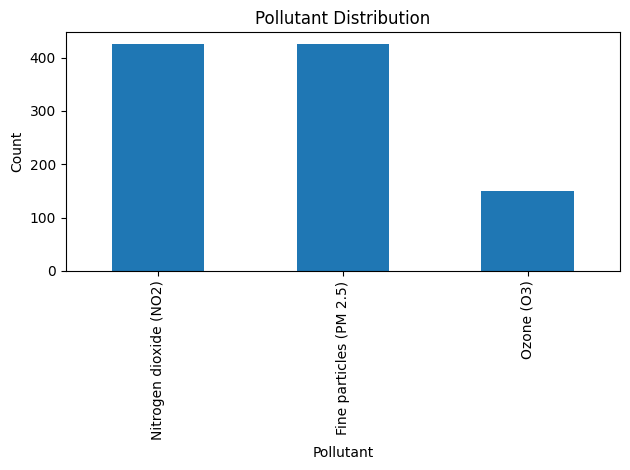

In [7]:
df['name'].value_counts().plot(kind='bar')
plt.title('Pollutant Distribution')
plt.xlabel('Pollutant')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

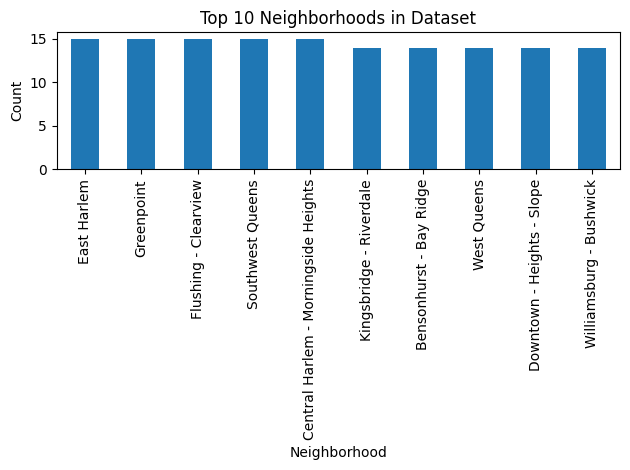

In [8]:
df['geo_place_name'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Neighborhoods in Dataset')
plt.xlabel('Neighborhood')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## Step 3: Bivariate Analysis
Exploring the relationship between pollutants and data values.

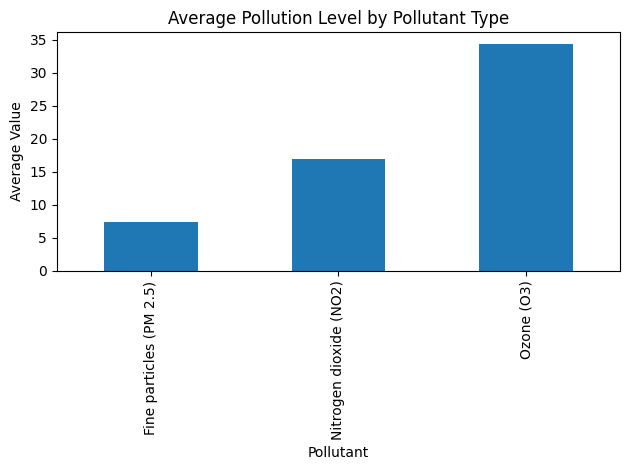

In [9]:
df['data_value'] = pd.to_numeric(df['data_value'], errors='coerce')
df.groupby('name')['data_value'].mean().plot(kind='bar')
plt.title('Average Pollution Level by Pollutant Type')
plt.xlabel('Pollutant')
plt.ylabel('Average Value')
plt.tight_layout()
plt.show()

## Observations
- The dataset contains 1,000 rows of air quality data across NYC neighborhoods
- Three main pollutants are tracked: NO2, PM2.5, and Ozone
- Ozone has the highest average pollution level across NYC neighborhoods
- Further analysis needed to connect pollution levels to asthma ER visit rates